# Intrinsic Jacobian analysis of FUCCI cell-cycle dynamics

This notebook is the shareable empirical application of the three reusable modules in this folder:

- `intrinsic_jacobian.py`: local intrinsic/ambient Jacobian estimation and reliability diagnostics;
- `connection_smoothing.py`: connection-aware smoothing across local tangent frames;
- `downstream_geometry.py`: divergence, strain, rotation, and acceleration diagnostics.

The input is the Mahdessian et al. FUCCI dataset prepared into RNA-state PCA coordinates and RNA-velocity PCA coordinates. Cell-cycle categories are measured independently by FACS. The notebook separates two evidence levels: the FACS-based DEG test is inferential (Wilcoxon with BH-FDR correction), while correlations between DEG expression and Jacobian divergence are descriptive and should not be interpreted as causal regulatory effects.

## 1. Setup and reproducibility configuration

Run this notebook from the `application_intrinsic jacobian` directory inside the ManfitVelo repository. The random seed and all analysis parameters are fixed below.

In [1]:
from pathlib import Path
import json
import sys
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import spearmanr

ROOT = Path.cwd().resolve()
if not (ROOT / 'intrinsic_jacobian.py').exists():
    raise RuntimeError('Start Jupyter from the application_intrinsic jacobian directory.')
MANFITVELO_ROOT = ROOT.parent
for path in (ROOT, MANFITVELO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from scripts.velocity_manifold_fitter import VelocityManifoldFitter
from intrinsic_jacobian import estimate_jacobian_field
from connection_smoothing import connection_aware_smooth
from downstream_geometry import (
    acceleration_decomposition, strain_rotation_decomposition,
    find_fixed_point_candidates, refine_fixed_point, classify_fixed_point,
)

warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

DATA_DIR = ROOT / 'datasets' / 'fucci_cellcycle'
K_GEOM = 30
T_ITERS = 5
SEED = 0
LAMBDA_J = 1.0
CATEGORY_ORDER = ['G1', 'S-ph', 'G2M']
CATEGORY_COLORS = {'G1': 'tab:blue', 'S-ph': 'tab:green', 'G2M': 'tab:red'}
print(f'Application: {ROOT}')
print(f'ManfitVelo:  {MANFITVELO_ROOT}')

Application: /Users/eurus2003/Downloads/RNA velocity/ManfitVelo/application_intrinsic jacobian
ManfitVelo:  /Users/eurus2003/Downloads/RNA velocity/ManfitVelo


## 2. Load the prepared FUCCI arrays

`X_fucci.npy` and `V_fucci.npy` contain the 30-dimensional PCA state and velocity coordinates. `expr_hvg_fucci.npy` contains log-normalized expression for 2,000 highly variable genes. The categorical phase and continuous pseudotime originate from the independent FUCCI/FACS measurements rather than RNA expression.

In [2]:
X_raw = np.load(DATA_DIR / 'X_fucci.npy')
V_raw = np.load(DATA_DIR / 'V_fucci.npy')
phase = np.load(DATA_DIR / 'phase_fucci.npy')
category = np.load(DATA_DIR / 'phase_category_fucci.npy', allow_pickle=True)
expr = np.load(DATA_DIR / 'expr_hvg_fucci.npy')
genes = np.array((DATA_DIR / 'genes_fucci.txt').read_text().splitlines())
boundaries = json.loads((DATA_DIR / 'checkpoint_boundaries_fucci.json').read_text())['transitions']

assert X_raw.shape == V_raw.shape
assert len(X_raw) == len(phase) == len(category) == len(expr)
assert expr.shape[1] == len(genes)
assert np.isfinite(X_raw).all() and np.isfinite(V_raw).all() and np.isfinite(expr).all()

pd.DataFrame({
    'value': [X_raw.shape[0], X_raw.shape[1], expr.shape[1], ', '.join(np.unique(category))]
}, index=['cells', 'PCA dimensions', 'HVGs', 'FACS categories'])

,value
cells,1067
PCA dimensions,30
HVGs,2000
FACS categories,"G1, G2M, S-ph"


## 3. ManfitVelo → intrinsic Jacobian → connection smoothing

We fit fixed intrinsic dimensions `d=1` and `d=2`. A fixed dimension is required because the current Jacobian estimator uses dense `(n, D, d)` tangent-basis arrays. Derivative neighborhoods are rebuilt adaptively inside `estimate_jacobian_field`; the ManfitVelo neighbor graph is used for connection-aware smoothing.

In [3]:
def fit_dimension(X, V, d):
    fitter = VelocityManifoldFitter(
        X, V, d_mode='global', global_d=d, k=K_GEOM, T=T_ITERS,
        eta_g=0.7, theta=0.02, kappa=0.0, bandwidth_mode='variable',
        use_PCA=False, random_state=SEED, lambda_v=1.0,
        velocity_covariance_mode='uncentered',
        velocity_trace_normalization='match_position_trace',
    )
    source = fitter.fit(update_mode='normal_only', return_dict=True)
    field = estimate_jacobian_field(
        source['X'], source['V'], np.asarray(source['U']), source['P'], d,
        k0=source['neighbors'].shape[1],
    )
    raw_geometry = strain_rotation_decomposition(field.J_intrinsic)
    smooth = connection_aware_smooth(
        field.J_intrinsic, np.asarray(source['U']), source['neighbors'], source['weights'],
        field.n_eff, field.kappa_intrinsic, field.residual_intrinsic,
        lambda_J=LAMBDA_J, abstained=field.abstained,
    )
    if smooth.cg_info != 0:
        raise RuntimeError(f'CG did not converge for d={d}: info={smooth.cg_info}')
    smooth_geometry = strain_rotation_decomposition(smooth.J_smoothed)
    acceleration = acceleration_decomposition(field.J_amb, field.N, source['V'], source['P'])
    return {'source': source, 'field': field, 'raw': raw_geometry,
            'smooth': smooth, 'geometry': smooth_geometry, 'acceleration': acceleration}

fits = {d: fit_dimension(X_raw, V_raw, d) for d in (1, 2)}
diagnostics = pd.DataFrame({
    d: {
        'reliable fraction': fits[d]['field'].reliable.mean(),
        'median n_eff': np.nanmedian(fits[d]['field'].n_eff),
        'median intrinsic condition number': np.nanmedian(fits[d]['field'].kappa_intrinsic),
        'CG iterations': fits[d]['smooth'].n_iter,
    } for d in (1, 2)
}).T
diagnostics.index.name = 'intrinsic dimension'
diagnostics

,reliable fraction,median n_eff,median intrinsic condition number,CG iterations
intrinsic dimension,,,,
1,0.804124,20.406356,1.00000,22.0
2,0.746017,20.351987,1.76745,35.0


## 4. Geometry on the FUCCI state space

Divergence is `trace(J)` and measures local expansion or contraction of the fitted flow. In `d=2`, the symmetric traceless component gives shear and the antisymmetric component gives a gauge-invariant rotation magnitude. These are local geometric diagnostics, not direct gene-regulatory coefficients.

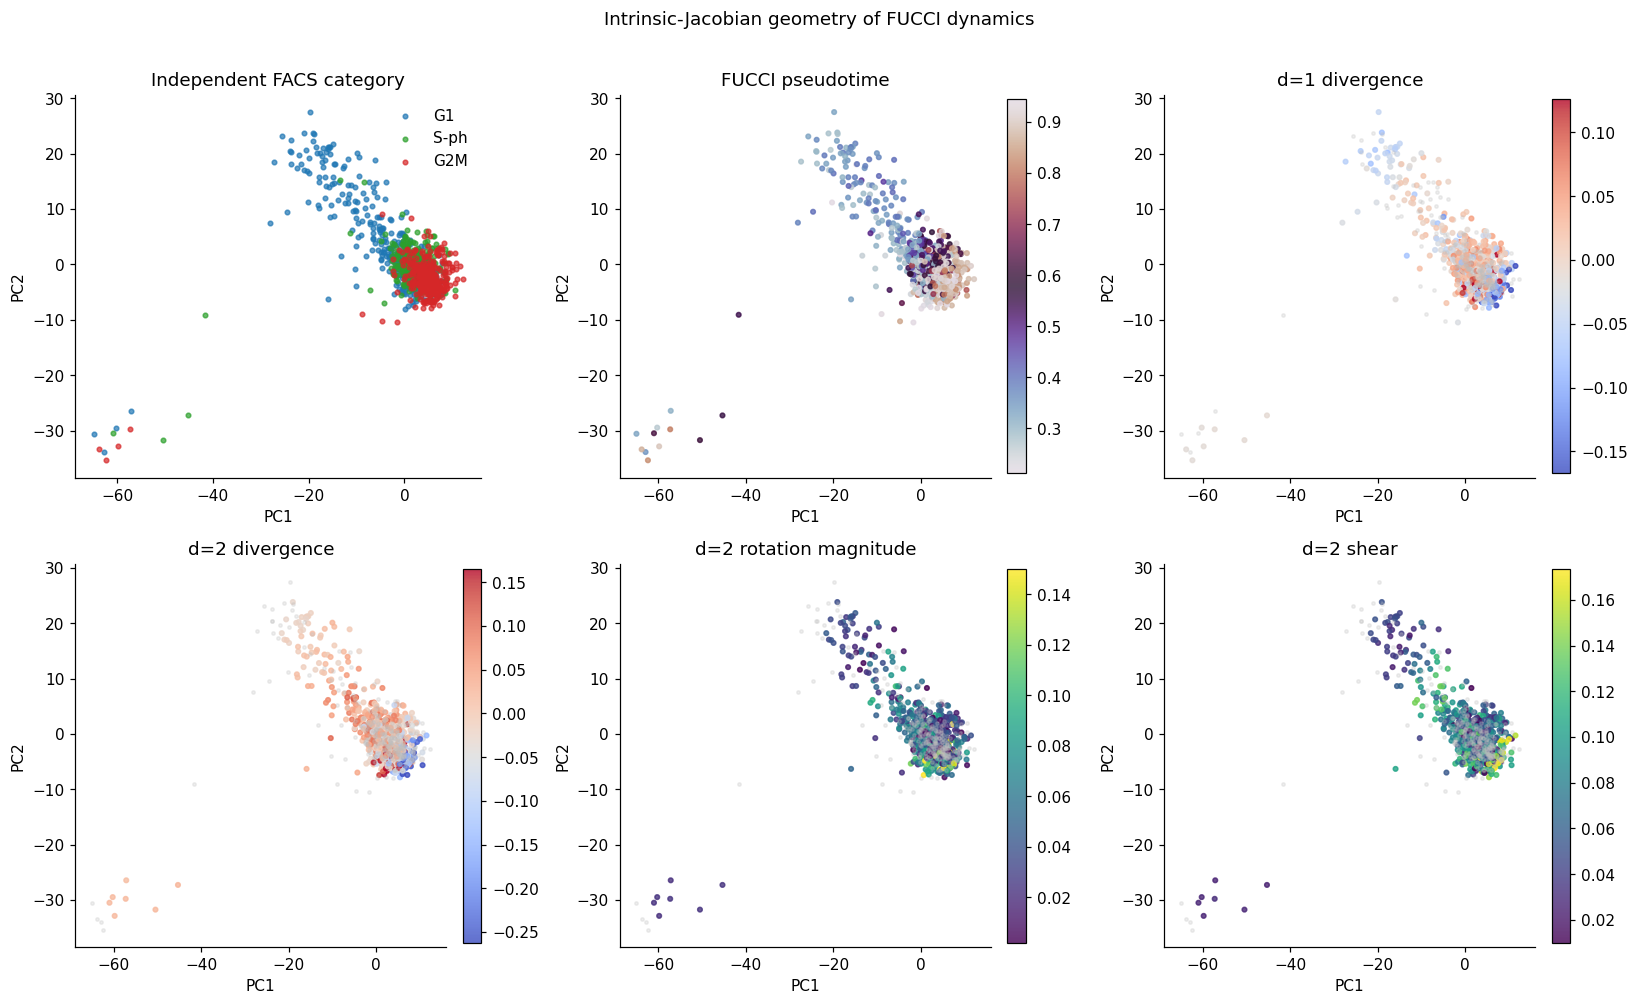

In [4]:
fit1, fit2 = fits[1], fits[2]
panels = [
    (phase, 'twilight', 'FUCCI pseudotime', None),
    (fit1['geometry'].divergence, 'coolwarm', 'd=1 divergence', fit1['field'].reliable),
    (fit2['geometry'].divergence, 'coolwarm', 'd=2 divergence', fit2['field'].reliable),
    (fit2['geometry'].vorticity_mag, 'viridis', 'd=2 rotation magnitude', fit2['field'].reliable),
    (fit2['geometry'].shear, 'viridis', 'd=2 shear', fit2['field'].reliable),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
ax = axes[0, 0]
for label in CATEGORY_ORDER:
    mask = category == label
    ax.scatter(X_raw[mask, 0], X_raw[mask, 1], s=9, alpha=.7,
               color=CATEGORY_COLORS[label], label=label)
ax.set_title('Independent FACS category'); ax.legend(frameon=False)
# Unreliable/abstained cells are excluded from the percentile scale and the
# colored scatter, and shown as light gray instead -- consistent with the
# Gauss-decomposition panels below, so a noisy or ill-conditioned local fit
# never silently shapes the color scale or reads as signal in this figure.
for ax, (values, cmap, title, reliable_mask) in zip(axes.ravel()[1:], panels):
    if reliable_mask is None:
        lo, hi = np.nanpercentile(values, [2, 98])
        shown = np.clip(values, lo, hi)
        artist = ax.scatter(X_raw[:, 0], X_raw[:, 1], c=shown, cmap=cmap, s=9, alpha=.8)
    else:
        lo, hi = np.nanpercentile(values[reliable_mask], [2, 98])
        shown = np.clip(values, lo, hi)
        artist = ax.scatter(X_raw[reliable_mask, 0], X_raw[reliable_mask, 1],
                             c=shown[reliable_mask], cmap=cmap, s=9, alpha=.8)
        ax.scatter(X_raw[~reliable_mask, 0], X_raw[~reliable_mask, 1], s=5, color='.75', alpha=.25)
    ax.set_title(title); fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
for ax in axes.ravel():
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.suptitle('Intrinsic-Jacobian geometry of FUCCI dynamics', y=1.01)
fig.tight_layout()
plt.show()

dimension,d=1,d=2
FACS phase,,
G1,-0.003851,0.017786
S-ph,0.030656,0.025737
G2M,-0.017823,-0.042030


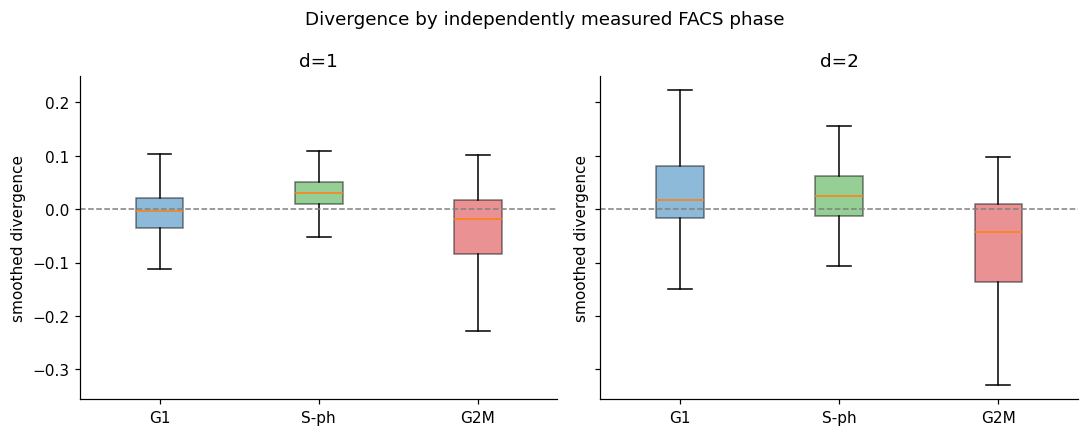

In [5]:
divergence_by_phase = pd.DataFrame({
    'FACS phase': np.repeat(CATEGORY_ORDER, 2),
    'dimension': ['d=1', 'd=2'] * 3,
    'median divergence': [
        np.median(fits[d]['geometry'].divergence[(category == label) & fits[d]['field'].reliable])
        for label in CATEGORY_ORDER for d in (1, 2)
    ],
})
display(divergence_by_phase.pivot(index='FACS phase', columns='dimension', values='median divergence').reindex(CATEGORY_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, d in zip(axes, (1, 2)):
    values = [
        fits[d]['geometry'].divergence[(category == label) & fits[d]['field'].reliable]
        for label in CATEGORY_ORDER
    ]
    boxes = ax.boxplot(values, tick_labels=CATEGORY_ORDER, patch_artist=True, showfliers=False)
    for box, label in zip(boxes['boxes'], CATEGORY_ORDER):
        box.set_facecolor(CATEGORY_COLORS[label]); box.set_alpha(.5)
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.set_title(f'd={d}'); ax.set_ylabel('smoothed divergence')
fig.suptitle('Divergence by independently measured FACS phase')
fig.tight_layout()
plt.show()

## 5. Gauss decomposition: intrinsic change versus manifold bending

For a velocity field constrained to a curved state manifold, an ambient change in velocity has two geometrically different sources:

$$D_vv = \underbrace{\nabla_v^{\mathcal M}v}_{a_{\mathrm{int}}} + \underbrace{\mathrm{II}(v,v)}_{a_{\mathrm{normal}}}.$$

- **Intrinsic acceleration** $a_{\mathrm{int}}=J_{\mathrm{amb}}v$ is tangent to the fitted manifold. It describes how the flow changes within the accessible cell-state geometry—for example, speeding up, slowing down, or turning within that state space.
- **Normal acceleration** $a_{\mathrm{normal}}=Nv$ is perpendicular to the fitted manifold. It is the ambient direction change required because the state manifold itself bends; it can be nonzero even when the intrinsic dynamics is locally unchanged.
- **Bending ratio** $R_{\mathrm{bend}}=\|a_{\mathrm{normal}}\|/(\|a_{\mathrm{int}}\|+\epsilon)$ is larger where the observed ambient velocity change is more geometry-dominated than intrinsic-dynamics-dominated. It becomes unstable when intrinsic acceleration is nearly zero, so we show `log10(1 + R_bend)` and interpret it descriptively.

Here ‘normal’ and ‘tangent’ are relative to the ManfitVelo manifold in 30-dimensional PCA space. They are not physical forces, and neither component is a direct gene-regulatory coefficient.

In [6]:
gauss = fits[2]['acceleration']
gauss_ok = fits[2]['field'].reliable
a_int_norm = np.linalg.norm(gauss.a_int, axis=1)
a_normal_norm = np.linalg.norm(gauss.a_normal, axis=1)
a_ambient_norm = np.linalg.norm(gauss.a_amb, axis=1)
log_bending_ratio = np.log10(1.0 + gauss.R_bend)

identity_error = np.linalg.norm(gauss.a_amb - gauss.a_int - gauss.a_normal, axis=1)
identity_scale = a_ambient_norm + a_int_norm + a_normal_norm + 1e-12
relative_identity_error = identity_error / identity_scale
orthogonality = np.abs(np.einsum('ni,ni->n', gauss.a_int, gauss.a_normal))
orthogonality /= a_int_norm * a_normal_norm + 1e-12

pd.Series({
    'reliable cells': int(gauss_ok.sum()),
    'max relative decomposition error': np.nanmax(relative_identity_error[gauss_ok]),
    'median |cos(tangent, normal)|': np.nanmedian(orthogonality[gauss_ok]),
    'median ||a_intrinsic||': np.nanmedian(a_int_norm[gauss_ok]),
    'median ||a_normal||': np.nanmedian(a_normal_norm[gauss_ok]),
    'median R_bend': np.nanmedian(gauss.R_bend[gauss_ok]),
}, name='d=2 Gauss-decomposition diagnostic')

reliable cells                      7.960000e+02
max relative decomposition error    1.743063e-16
median |cos(tangent, normal)|       5.691259e-16
median ||a_intrinsic||              8.368465e-02
median ||a_normal||                 7.886756e-02
median R_bend                       8.460532e-01
Name: d=2 Gauss-decomposition diagnostic, dtype: float64

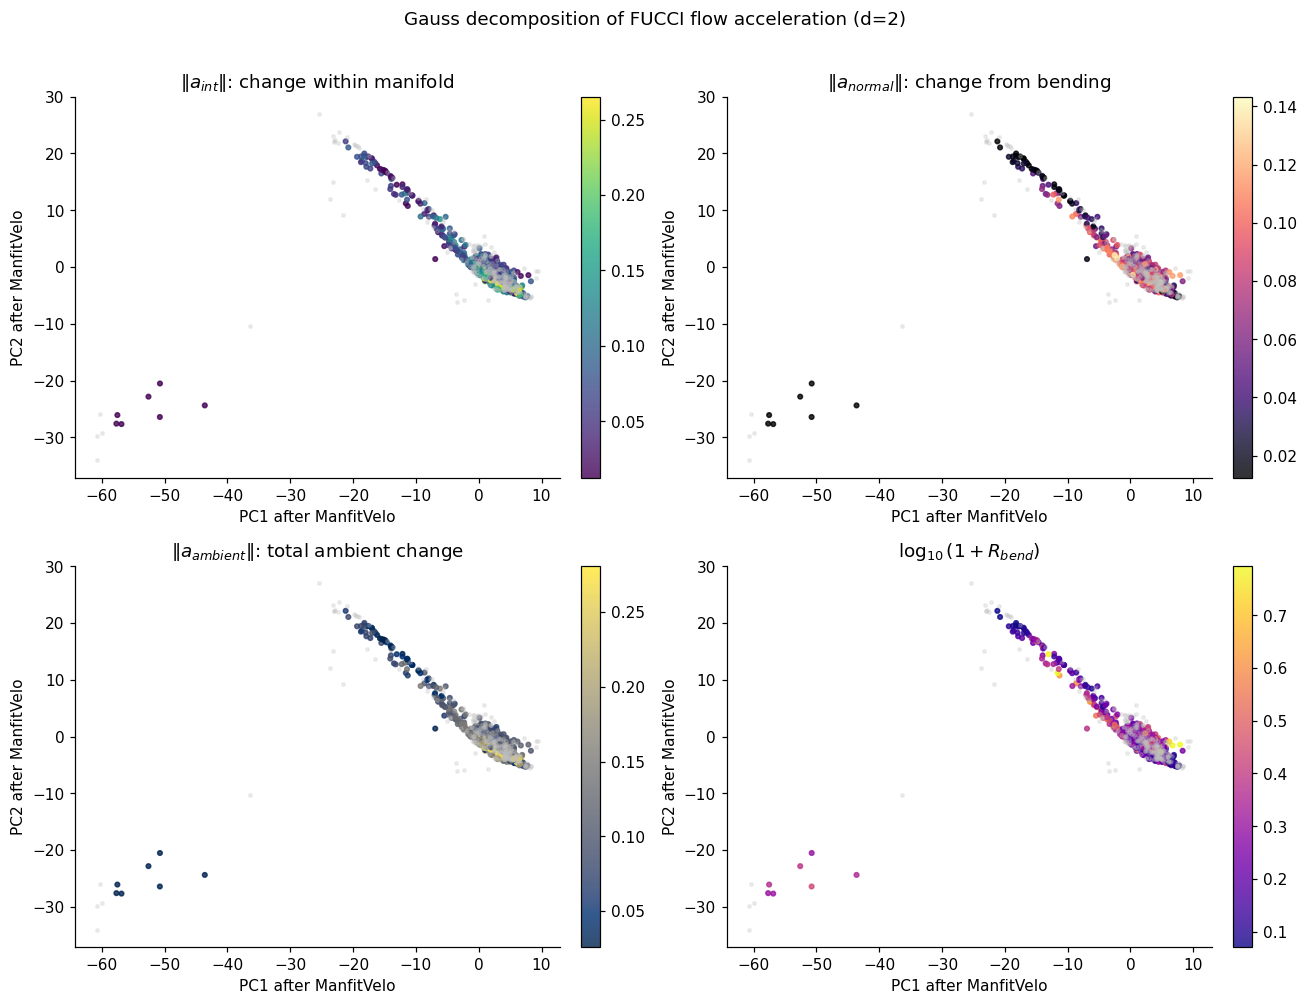

,n reliable,median ||a_intrinsic||,median ||a_normal||,median R_bend
FACS phase,,,,
G1,260,0.102810,0.084559,0.645944
S-ph,258,0.071028,0.072958,1.041629
G2M,278,0.090577,0.080560,0.833910


In [7]:
gauss_panels = [
    (a_int_norm, 'viridis', r'$\|a_{int}\|$: change within manifold'),
    (a_normal_norm, 'magma', r'$\|a_{normal}\|$: change from bending'),
    (a_ambient_norm, 'cividis', r'$\|a_{ambient}\|$: total ambient change'),
    (log_bending_ratio, 'plasma', r'$\log_{10}(1+R_{bend})$'),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
X_gauss = fits[2]['source']['X']
for ax, (values, cmap, title) in zip(axes.ravel(), gauss_panels):
    lo, hi = np.nanpercentile(values[gauss_ok], [2, 98])
    shown = np.clip(values, lo, hi)
    artist = ax.scatter(X_gauss[gauss_ok, 0], X_gauss[gauss_ok, 1],
                         c=shown[gauss_ok], cmap=cmap, s=9, alpha=.8)
    ax.scatter(X_gauss[~gauss_ok, 0], X_gauss[~gauss_ok, 1], s=5, color='.75', alpha=.25)
    ax.set(title=title, xlabel='PC1 after ManfitVelo', ylabel='PC2 after ManfitVelo')
    fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
fig.suptitle('Gauss decomposition of FUCCI flow acceleration (d=2)', y=1.01)
fig.tight_layout()
plt.show()

gauss_phase_rows = []
for label in CATEGORY_ORDER:
    mask = gauss_ok & (category == label)
    gauss_phase_rows.append({
        'FACS phase': label, 'n reliable': int(mask.sum()),
        'median ||a_intrinsic||': np.median(a_int_norm[mask]),
        'median ||a_normal||': np.median(a_normal_norm[mask]),
        'median R_bend': np.median(gauss.R_bend[mask]),
    })
pd.DataFrame(gauss_phase_rows).set_index('FACS phase')

## 6. Candidate fixed points and Jacobian-eigenvalue classification

A sampled single-cell field rarely contains a point with exactly zero velocity. We therefore identify reliable cells whose fitted speed is a local minimum on the ManfitVelo neighbor graph. At each candidate, one trust-region-capped Newton step estimates where the local linear model predicts `v=0`; the eigenvalues of the full, non-symmetric intrinsic Jacobian classify the local flow as attractor, repeller, or saddle and as node or spiral. Classification is evaluated at the observed candidate cell because a capped refinement is evidence that the extrapolated location lies outside the local model's trusted neighborhood.

In [8]:
fixed_fit = fits[2]
fixed_source, fixed_field = fixed_fit['source'], fixed_fit['field']
candidate_indices = find_fixed_point_candidates(
    fixed_source['V'], fixed_source['neighbors'], fixed_field.reliable, local_min_only=True
)
fixed_rows = []
for cell_index in candidate_indices:
    neighbor_index = fixed_source['neighbors'][cell_index]
    local_scale = float(np.mean(np.linalg.norm(
        fixed_source['X'][neighbor_index] - fixed_source['X'][cell_index], axis=1
    )))
    refinement = refine_fixed_point(
        fixed_source['X'][cell_index], fixed_source['V'][cell_index],
        fixed_source['U'][cell_index], fixed_field.J_intrinsic[cell_index], local_scale
    )
    classification = classify_fixed_point(fixed_field.J_intrinsic[cell_index])
    eig_text = ', '.join(f'{value.real:.3f}{value.imag:+.3f}i' for value in classification.eigenvalues)
    fixed_rows.append({
        'cell index': int(cell_index), 'FUCCI phase': phase[cell_index],
        'FACS category': category[cell_index],
        'speed': np.linalg.norm(fixed_source['V'][cell_index]),
        'kind': classification.kind, 'motion': classification.motion,
        'eigenvalues': eig_text, 'step capped': refinement.step_capped,
        'Newton step / local scale': np.linalg.norm(refinement.delta_local) / local_scale,
    })
fixed_points = pd.DataFrame(fixed_rows).sort_values('speed').reset_index(drop=True)
print(f'{len(fixed_points)} local-speed-minimum candidates')
print('kind:', fixed_points['kind'].value_counts().to_dict())
print('motion:', fixed_points['motion'].value_counts().to_dict())
print(f"step capped: {fixed_points['step capped'].mean():.1%}")
fixed_points.head(15).style.format({
    'FUCCI phase': '{:.3f}', 'speed': '{:.3f}',
    'Newton step / local scale': '{:.3f}',
})

31 local-speed-minimum candidates
kind: {'saddle': 17, 'repeller': 7, 'attractor': 7}
motion: {'node': 23, 'spiral': 8}
step capped: 96.8%


,cell index,FUCCI phase,FACS category,speed,kind,motion,eigenvalues,step capped,Newton step / local scale
0,92,0.378,G1,0.258,saddle,node,"-0.027+0.000i, 0.132+0.000i",True,0.500
1,20,0.335,G1,0.307,saddle,node,"-0.067+0.000i, 0.099+0.000i",False,0.424
2,44,0.881,G2M,0.328,repeller,spiral,"0.022+0.062i, 0.022-0.062i",True,0.500
3,1044,0.714,S-ph,0.337,attractor,node,"-0.119+0.000i, -0.028+0.000i",True,0.500
4,551,0.860,G2M,0.355,saddle,node,"-0.143+0.000i, 0.030+0.000i",True,0.500
5,25,0.831,G2M,0.356,attractor,node,"-0.087+0.000i, -0.266+0.000i",True,0.500
6,542,0.646,S-ph,0.407,saddle,node,"-0.018+0.000i, 0.071+0.000i",True,0.500
7,987,0.954,G2M,0.463,attractor,node,"-0.002+0.000i, -0.141+0.000i",True,0.500
8,675,0.467,S-ph,0.473,repeller,spiral,"0.049+0.012i, 0.049-0.012i",True,0.500
9,591,0.912,G2M,0.518,repeller,spiral,"0.056+0.014i, 0.056-0.014i",True,0.500


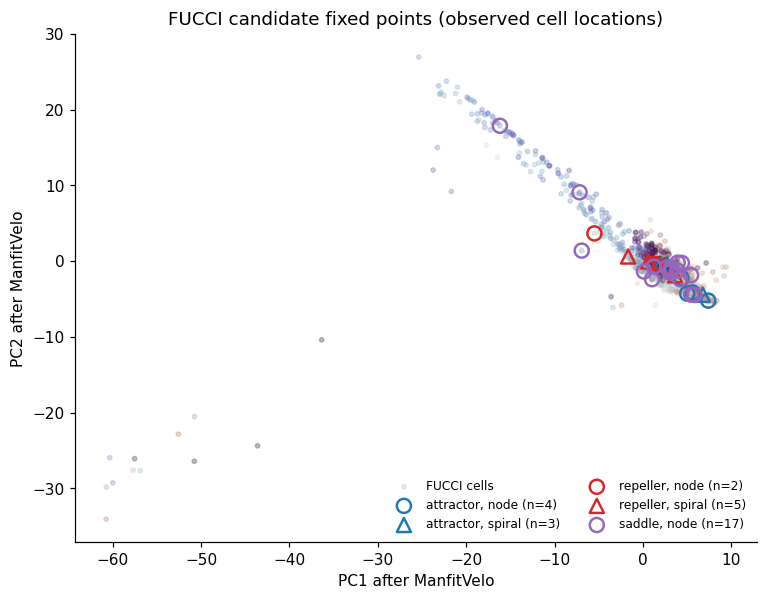

kind,attractor,repeller,saddle
FACS category,,,
G1,1,2,4
S-ph,2,3,6
G2M,4,2,7


In [9]:
kind_colors = {'attractor': 'tab:blue', 'repeller': 'tab:red', 'saddle': 'tab:purple'}
motion_markers = {'node': 'o', 'spiral': '^'}
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(fixed_source['X'][:, 0], fixed_source['X'][:, 1], c=phase, cmap='twilight',
           s=8, alpha=.28, label='FUCCI cells')
for (kind, motion), group in fixed_points.groupby(['kind', 'motion']):
    ii = group['cell index'].to_numpy(dtype=int)
    ax.scatter(fixed_source['X'][ii, 0], fixed_source['X'][ii, 1], s=85,
               facecolors='none', edgecolors=kind_colors[kind], marker=motion_markers[motion],
               linewidths=1.6, label=f'{kind}, {motion} (n={len(ii)})')
ax.set(xlabel='PC1 after ManfitVelo', ylabel='PC2 after ManfitVelo',
       title='FUCCI candidate fixed points (observed cell locations)')
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.show()

pd.crosstab(fixed_points['FACS category'], fixed_points['kind']).reindex(CATEGORY_ORDER).fillna(0).astype(int)

**Stability caveat.** Most FUCCI candidates require a capped Newton step, so the local linear model does not support a precise extrapolated zero-velocity location. The plot consequently shows observed local-speed-minimum cells, not the refined coordinates. These are candidate dynamical structures and a demonstration of the classification machinery, not confirmed biological fixed points.

## 7. Descriptive checkpoint alignment

Smoothed divergence is summarized by its median in 24 pseudotime bins and sign changes are compared with FACS-derived category boundaries. The categorical labels are independent measurements, but the continuous pseudotime is a polar-angle construction from FUCCI intensities and the proximity values below do not have an attached significance test.

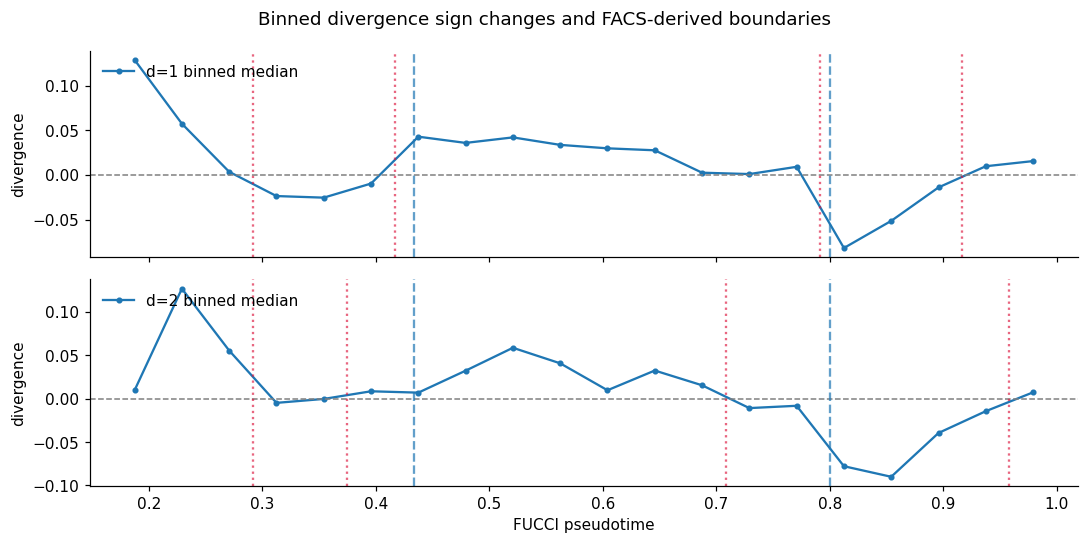

,d,boundary,boundary phase,nearest sign change,circular distance
0,1,G1->S-ph,0.433333,0.416667,0.016667
1,1,S-ph->G2M,0.800000,0.791667,0.008333
2,2,G1->S-ph,0.433333,0.375000,0.058333
3,2,S-ph->G2M,0.800000,0.708333,0.091667


In [10]:
def binned_divergence_transitions(phase, divergence, reliable, n_bins=24):
    edges = np.linspace(0, 1, n_bins + 1)
    bin_index = np.clip(np.digitize(phase, edges) - 1, 0, n_bins - 1)
    medians = np.full(n_bins, np.nan)
    for b in range(n_bins):
        mask = reliable & (bin_index == b)
        if mask.any():
            medians[b] = np.median(divergence[mask])
    transitions = []
    for b in range(n_bins):
        nxt = (b + 1) % n_bins
        if np.isfinite(medians[b]) and np.isfinite(medians[nxt]):
            if np.sign(medians[b]) != np.sign(medians[nxt]) and np.sign(medians[b]) != 0:
                transitions.append(float(edges[nxt]))
    return (edges[:-1] + edges[1:]) / 2, medians, transitions

transition_results = {}
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, d in zip(axes, (1, 2)):
    centers, medians, transitions = binned_divergence_transitions(
        phase, fits[d]['geometry'].divergence, fits[d]['field'].reliable
    )
    transition_results[d] = transitions
    ax.plot(centers, medians, marker='o', ms=3, label=f'd={d} binned median')
    ax.axhline(0, color='.5', linestyle='--', linewidth=1)
    for value in transitions:
        ax.axvline(value, color='crimson', linestyle=':', alpha=.65)
    for value in boundaries.values():
        ax.axvline(value, color='tab:blue', linestyle='--', alpha=.7)
    ax.set_ylabel('divergence'); ax.legend(frameon=False, loc='upper left')
axes[-1].set_xlabel('FUCCI pseudotime')
fig.suptitle('Binned divergence sign changes and FACS-derived boundaries')
fig.tight_layout()
plt.show()

def circular_distance(a, b):
    delta = abs(a - b) % 1.0
    return min(delta, 1.0 - delta)

alignment_rows = []
for d, transitions in transition_results.items():
    for name, boundary in boundaries.items():
        if not transitions:
            # No binned sign change was detected for this dimension at all
            # (e.g. divergence never flips sign within the chosen bins) --
            # report "no match" instead of crashing on min() over an empty
            # sequence.
            alignment_rows.append({'d': d, 'boundary': name, 'boundary phase': boundary,
                                   'nearest sign change': np.nan,
                                   'circular distance': np.nan})
            continue
        nearest = min(transitions, key=lambda x: circular_distance(x, boundary))
        alignment_rows.append({'d': d, 'boundary': name, 'boundary phase': boundary,
                               'nearest sign change': nearest,
                               'circular distance': circular_distance(nearest, boundary)})
pd.DataFrame(alignment_rows)

## 8. Before and after ManfitVelo

The same fixed PC1–PC2 axes are used before and after fitting. This panel shows how ManfitVelo changes positions and projects/denoises velocities before the Jacobian is estimated.

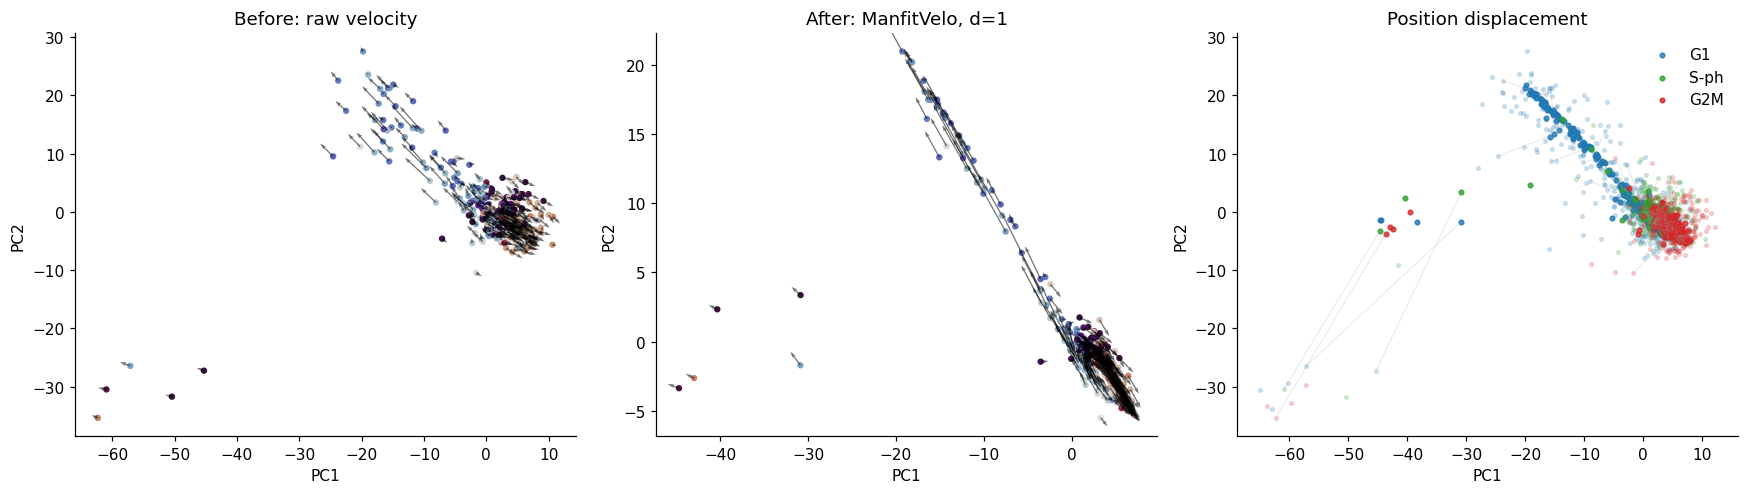

count    1067.000000
mean        8.766021
std         6.160385
min         3.419277
50%         7.655421
90%        11.661865
max        68.040915
Name: displacement in PCA coordinates, dtype: float64

In [11]:
X_fit, V_fit = fit1['source']['X'], fit1['source']['V']
step = 3
idx = np.arange(0, len(X_raw), step)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, X, V, title in [
    (axes[0], X_raw, V_raw, 'Before: raw velocity'),
    (axes[1], X_fit, V_fit, 'After: ManfitVelo, d=1'),
]:
    artist = ax.scatter(X[idx, 0], X[idx, 1], c=phase[idx], cmap='twilight', s=10)
    ax.quiver(X[idx, 0], X[idx, 1], V[idx, 0], V[idx, 1],
              angles='xy', scale_units='xy', scale=.3, width=.0025, alpha=.55)
    ax.set_title(title)
for label in CATEGORY_ORDER:
    mask = category == label
    axes[2].scatter(X_raw[mask, 0], X_raw[mask, 1], s=6, alpha=.18, color=CATEGORY_COLORS[label])
    axes[2].scatter(X_fit[mask, 0], X_fit[mask, 1], s=9, alpha=.8, color=CATEGORY_COLORS[label], label=label)
for i in np.arange(0, len(X_raw), 6):
    axes[2].plot([X_raw[i, 0], X_fit[i, 0]], [X_raw[i, 1], X_fit[i, 1]], color='.6', lw=.35, alpha=.4)
axes[2].set_title('Position displacement'); axes[2].legend(frameon=False)
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.tight_layout()
plt.show()

displacement = np.linalg.norm(X_fit - X_raw, axis=1)
pd.Series(displacement).describe(percentiles=[.5, .9]).rename('displacement in PCA coordinates')

## 9. Differential expression using independent FACS labels

For each FACS phase, genes are ranked one-versus-rest with the Wilcoxon test. Scanpy applies Benjamini–Hochberg correction across genes. This stage is a formal statistical analysis because the phase labels were measured independently of the RNA expression matrix.

In [12]:
adata = ad.AnnData(X=expr.copy())
adata.var_names = genes
adata.obs['FACS_phase'] = pd.Categorical(category, categories=CATEGORY_ORDER)
sc.tl.rank_genes_groups(adata, groupby='FACS_phase', method='wilcoxon')

deg_rows = []
for group in CATEGORY_ORDER:
    ranked = adata.uns['rank_genes_groups']
    for gene, p_adj, log2fc in zip(ranked['names'][group], ranked['pvals_adj'][group], ranked['logfoldchanges'][group]):
        deg_rows.append({'gene': gene, 'FACS phase': group, 'p_adj': float(p_adj), 'log2FC': float(log2fc)})
deg = pd.DataFrame(deg_rows)
significant = deg[deg['p_adj'] < .05]
top_deg = significant.sort_values('p_adj').groupby('FACS phase', observed=True).head(15)
print(f'{len(significant):,} significant gene–phase pairs at BH-FDR < 0.05')
print(f'{top_deg.gene.nunique()} unique genes retained from the top 15 per phase')
top_deg.groupby('FACS phase', observed=True).head(5).reset_index(drop=True)

1,340 significant gene–phase pairs at BH-FDR < 0.05
34 unique genes retained from the top 15 per phase


,gene,FACS phase,p_adj,log2FC
0,CDK1,G1,2.816622e-142,-4.313642
1,UBE2C,G1,2.250038e-118,-3.012104
2,UBE2C,G2M,5.715195e-106,2.354075
3,FAM83D,G2M,8.660810e-96,2.923079
4,CDK1,G2M,1.561651e-95,2.641082
5,TOP2A,G2M,8.548943e-94,2.103839
6,KPNA2,G2M,1.230321e-91,1.440877
7,TOP2A,G1,3.199269e-90,-2.805163
8,HJURP,G1,4.481754e-90,-3.638630
9,ZWINT,G1,4.481754e-90,-1.756072


## 10. DEG expression versus Jacobian divergence

For the independently prioritized DEGs, we calculate Spearman correlation with the smoothed divergence field among reliable cells. This second stage is descriptive: the table is useful as biological corroboration and hypothesis generation, but the correlations are not an independently validated causal or mechanistic result.

In [13]:
gene_index = {gene: i for i, gene in enumerate(genes)}
corr_rows = []
for gene in top_deg['gene'].unique():
    rows = top_deg[top_deg['gene'] == gene]
    row = {
        'gene': gene,
        'DEG in': ', '.join(rows['FACS phase'].astype(str)),
        'min adjusted p': rows['p_adj'].min(),
        'max |log2FC|': rows['log2FC'].abs().max(),
    }
    for d in (1, 2):
        reliable = fits[d]['field'].reliable
        rho = spearmanr(expr[reliable, gene_index[gene]], fits[d]['geometry'].divergence[reliable]).statistic
        row[f'corr divergence d={d}'] = rho
    corr_rows.append(row)
correlations = pd.DataFrame(corr_rows)
correlations = correlations.iloc[np.argsort(-np.abs(correlations['corr divergence d=1'].to_numpy()))].reset_index(drop=True)
correlations.head(20).style.format({
    'min adjusted p': '{:.2e}', 'max |log2FC|': '{:.2f}',
    'corr divergence d=1': '{:.3f}', 'corr divergence d=2': '{:.3f}',
})

,gene,DEG in,min adjusted p,max |log2FC|,corr divergence d=1,corr divergence d=2
0,PCNA,S-ph,2.27e-65,0.95,0.403,0.201
1,FAM111B,S-ph,7.99e-77,2.86,0.391,0.186
2,CDC6,S-ph,5.08e-61,1.67,0.387,0.174
3,MCM3,S-ph,9.85e-52,1.15,0.371,0.225
4,MCM2,S-ph,1.94e-48,1.38,0.355,0.171
5,GINS2,S-ph,1.37e-56,1.25,0.341,0.182
6,PRIM1,"S-ph, G1",5.41e-45,1.32,0.331,0.102
7,CDC20,S-ph,5.57e-34,0.61,-0.315,-0.287
8,KPNA2,"G2M, G1",1.23e-91,1.44,-0.311,-0.451
9,CCNB1,S-ph,9.62e-38,0.78,-0.299,-0.229


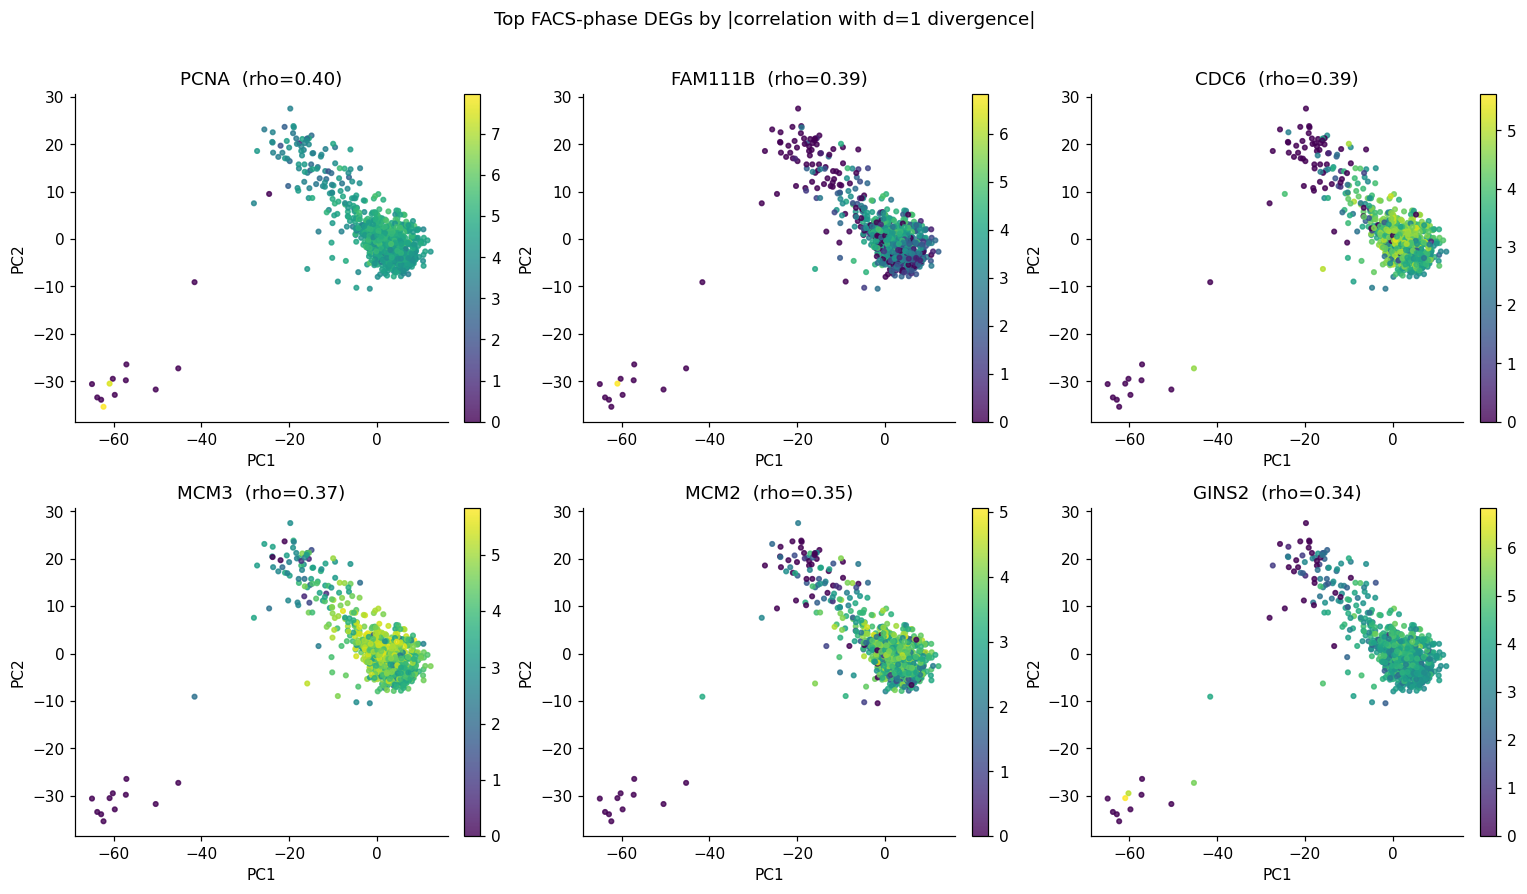

In [14]:
top6 = correlations.head(6)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (_, row) in zip(axes.ravel(), top6.iterrows()):
    values = expr[:, gene_index[row['gene']]]
    artist = ax.scatter(X_raw[:, 0], X_raw[:, 1], c=values, cmap='viridis', s=9, alpha=.8)
    ax.set_title(f"{row['gene']}  (rho={row['corr divergence d=1']:.2f})")
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
fig.suptitle('Top FACS-phase DEGs by |correlation with d=1 divergence|', y=1.01)
fig.tight_layout()
plt.show()

## 11. Interpretation

The reproducible empirical pattern is that S-phase/DNA-replication genes such as **PCNA, CDC6, MCM2, MCM3, GINS2, and PRIM1** tend to correlate positively with divergence, whereas G2M/mitotic genes such as **CDK1, UBE2C, TOP2A, AURKA, CCNB1, and CDC20** tend to correlate negatively. This agrees with the coarser category-level pattern of positive S-phase and negative G2M median divergence.

What is supported:

- the three algorithm modules pass synthetic recovery, gauge-equivariance, decomposition, and smoothing tests;
- the reported DEGs differ across independently measured FACS phases after BH-FDR correction;
- canonical cell-cycle genes show a coherent descriptive relationship with the inferred expansion/contraction field.

What is not established:

- divergence is not a gene-regulatory coefficient and does not establish causality;
- the DEG–divergence correlations have not received a second-stage multiple-testing analysis or external replication;
- `d=1` and `d=2` are sensitivity views of the same data, not independent biological replicates.